<a href="https://colab.research.google.com/github/ferhanbyr/data-analysis-project/blob/main/BitirmeProjesi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Bu çalışmada, öğrencilere ait demografik, akademik ve davranışsal değişkenler kullanılarak akademik başarıyı etkileyen faktörler incelenmiş, ardından öğrencilerin başarı düzeyleri makine öğrenmesi yöntemleri kullanılarak sınıflandırılmıştır. Çalışmanın amacı, akademik başarı üzerinde etkili olan değişkenleri belirlemek ve bu değişkenler yardımıyla öğrencilerin başarı düzeylerini tahmin edebilen açıklanabilir bir model oluşturmaktır.

*Veri seti, öğrencilerin akademik başarısını etkileyen demografik, ailesel ve davranışsal faktörleri içermektedir.*

**school**: Öğrencinin okulu (GP, MS)

**sex**: Cinsiyet (F: kadın, M: erkek)

**age**: Yaş

**address**: Yaşam alanı (U: kentsel, R: kırsal)

**famsize** : Aile büyüklüğü (LE3: ≤3, GT3: >3)

**Pstatus**: Ebeveyn durumu (T: birlikte, A: ayrı)



**Medu / Fedu: Anne / baba eğitim düzeyi**

(0: yok, 1: ilkokul, 2: ortaokul, 3: lise, 4: yükseköğrenim)

Mjob / Fjob: Anne / baba mesleği


**reason**: Okul tercih nedeni (home, reputation, course, other)

**guardian**: Veli (mother, father, other)

**traveltime**: Okula ulaşım süresi (1: <15 dk – 4: >60 dk)

**studytime**: Haftalık ders çalışma süresi (1: <2 saat – 4: >10 saat)

**failures**: Daha önce kalınan ders sayısı


**schoolsup / famsup**: Okul / aile desteği (yes, no)

**paid**: Ücretli özel ders (yes, no)

**activities**: Sosyal etkinlikler (yes, no)

**nursery**: Okul öncesi eğitim (yes, no)

**higher**: Yükseköğrenim hedefi (yes, no)

**internet**: Evde internet erişimi (yes, no)

**romantic**: Romantik ilişki durumu (yes, no)

**famrel**: Aile ilişkileri (1: çok kötü – 5: çok iyi)
**freetime**: Boş zaman (1: az – 5: çok)

**goout**: Dışarı çıkma sıklığı (1–5)

**Dalc / Walc**: Hafta içi / hafta sonu alkol tüketimi (1–5)

**health**: Sağlık durumu (1: kötü – 5: iyi)

**absences**: Devamsızlık sayısı

**G1 / G2 / G3**: 1., 2. dönem ve final notu

In [7]:
# Sayısal işlemler ve veri yapıları için
import numpy as np

# Veri okuma, düzenleme ve analiz işlemleri için
import pandas as pd

# Grafik ve görselleştirme işlemleri için
import matplotlib.pyplot as plt
import seaborn as sns


In [8]:
# Öğrenci başarı verisini CSV dosyasından okuyarak DataFrame'e aktarıyoruz
df = pd.read_csv("student-por.csv")

# Veri setinin ilk görünümünü incelemek için ekrana yazdırıyoruz
df

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,6,12,13,12
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,0,14,14,14
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,0,11,13,13
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
644,MS,F,19,R,GT3,T,2,3,services,other,...,5,4,2,1,2,5,4,10,11,10
645,MS,F,18,U,LE3,T,3,1,teacher,services,...,4,3,4,1,1,1,4,15,15,16
646,MS,F,18,U,GT3,T,1,1,other,other,...,1,1,1,1,1,5,6,11,12,9
647,MS,M,17,U,LE3,T,3,1,services,services,...,2,4,5,3,4,2,6,10,10,10


In [9]:
# Veri setinin genel yapısını incelemek için temel bilgileri görüntülüyoruz
print("Veri Seti Hakkında Temel Bilgiler")
print("---------------------------------")
df.info()


Veri Seti Hakkında Temel Bilgiler
---------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 649 entries, 0 to 648
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      649 non-null    object
 1   sex         649 non-null    object
 2   age         649 non-null    int64 
 3   address     649 non-null    object
 4   famsize     649 non-null    object
 5   Pstatus     649 non-null    object
 6   Medu        649 non-null    int64 
 7   Fedu        649 non-null    int64 
 8   Mjob        649 non-null    object
 9   Fjob        649 non-null    object
 10  reason      649 non-null    object
 11  guardian    649 non-null    object
 12  traveltime  649 non-null    int64 
 13  studytime   649 non-null    int64 
 14  failures    649 non-null    int64 
 15  schoolsup   649 non-null    object
 16  famsup      649 non-null    object
 17  paid        649 non-null    object
 18  activities  649 non-nu

Missing Values (Eksik Veri Kontrolü)

In [10]:
#Eksik veri kontrolü yapmak için gerekli komutu çalıştırıyoruz.
df.isnull().sum()



,0
school,0
sex,0
age,0
address,0
famsize,0
Pstatus,0
Medu,0
Fedu,0
Mjob,0
Fjob,0


In [11]:
#Veri setinin temel istatistiksel özet bilgisi
print("Veri Seti Hakkında Temel İstatistiksel Bilgiler")
print("---------------------------------")
df.describe().T


Veri Seti Hakkında Temel İstatistiksel Bilgiler
---------------------------------


,count,mean,std,min,25%,50%,75%,max
age,649.0,16.744222,1.218138,15.0,16.0,17.0,18.0,22.0
Medu,649.0,2.514638,1.134552,0.0,2.0,2.0,4.0,4.0
Fedu,649.0,2.306626,1.099931,0.0,1.0,2.0,3.0,4.0
traveltime,649.0,1.568567,0.748660,1.0,1.0,1.0,2.0,4.0
studytime,649.0,1.930663,0.829510,1.0,1.0,2.0,2.0,4.0
failures,649.0,0.221880,0.593235,0.0,0.0,0.0,0.0,3.0
famrel,649.0,3.930663,0.955717,1.0,4.0,4.0,5.0,5.0
freetime,649.0,3.180277,1.051093,1.0,3.0,3.0,4.0,5.0
goout,649.0,3.184900,1.175766,1.0,2.0,3.0,4.0,5.0
Dalc,649.0,1.502311,0.924834,1.0,1.0,1.0,2.0,5.0


Burada count değerinin tüm sütunlarının 649 olması eksik veri olmadığını doğruluyor. Min-Max aralıkları veri setinin mantığıyla uyumlu. Mean,median dağılımlar görülüyor.

In [12]:
#Veri setinin boyutu
print("Veri Setinin Boyutu (Satır, Sütun):")
df.shape

Veri Setinin Boyutu (Satır, Sütun):


(649, 33)

In [13]:
#Toplam veri sayısı
print("Toplam Veri Sayısı:")
df.size

Toplam Veri Sayısı:


21417

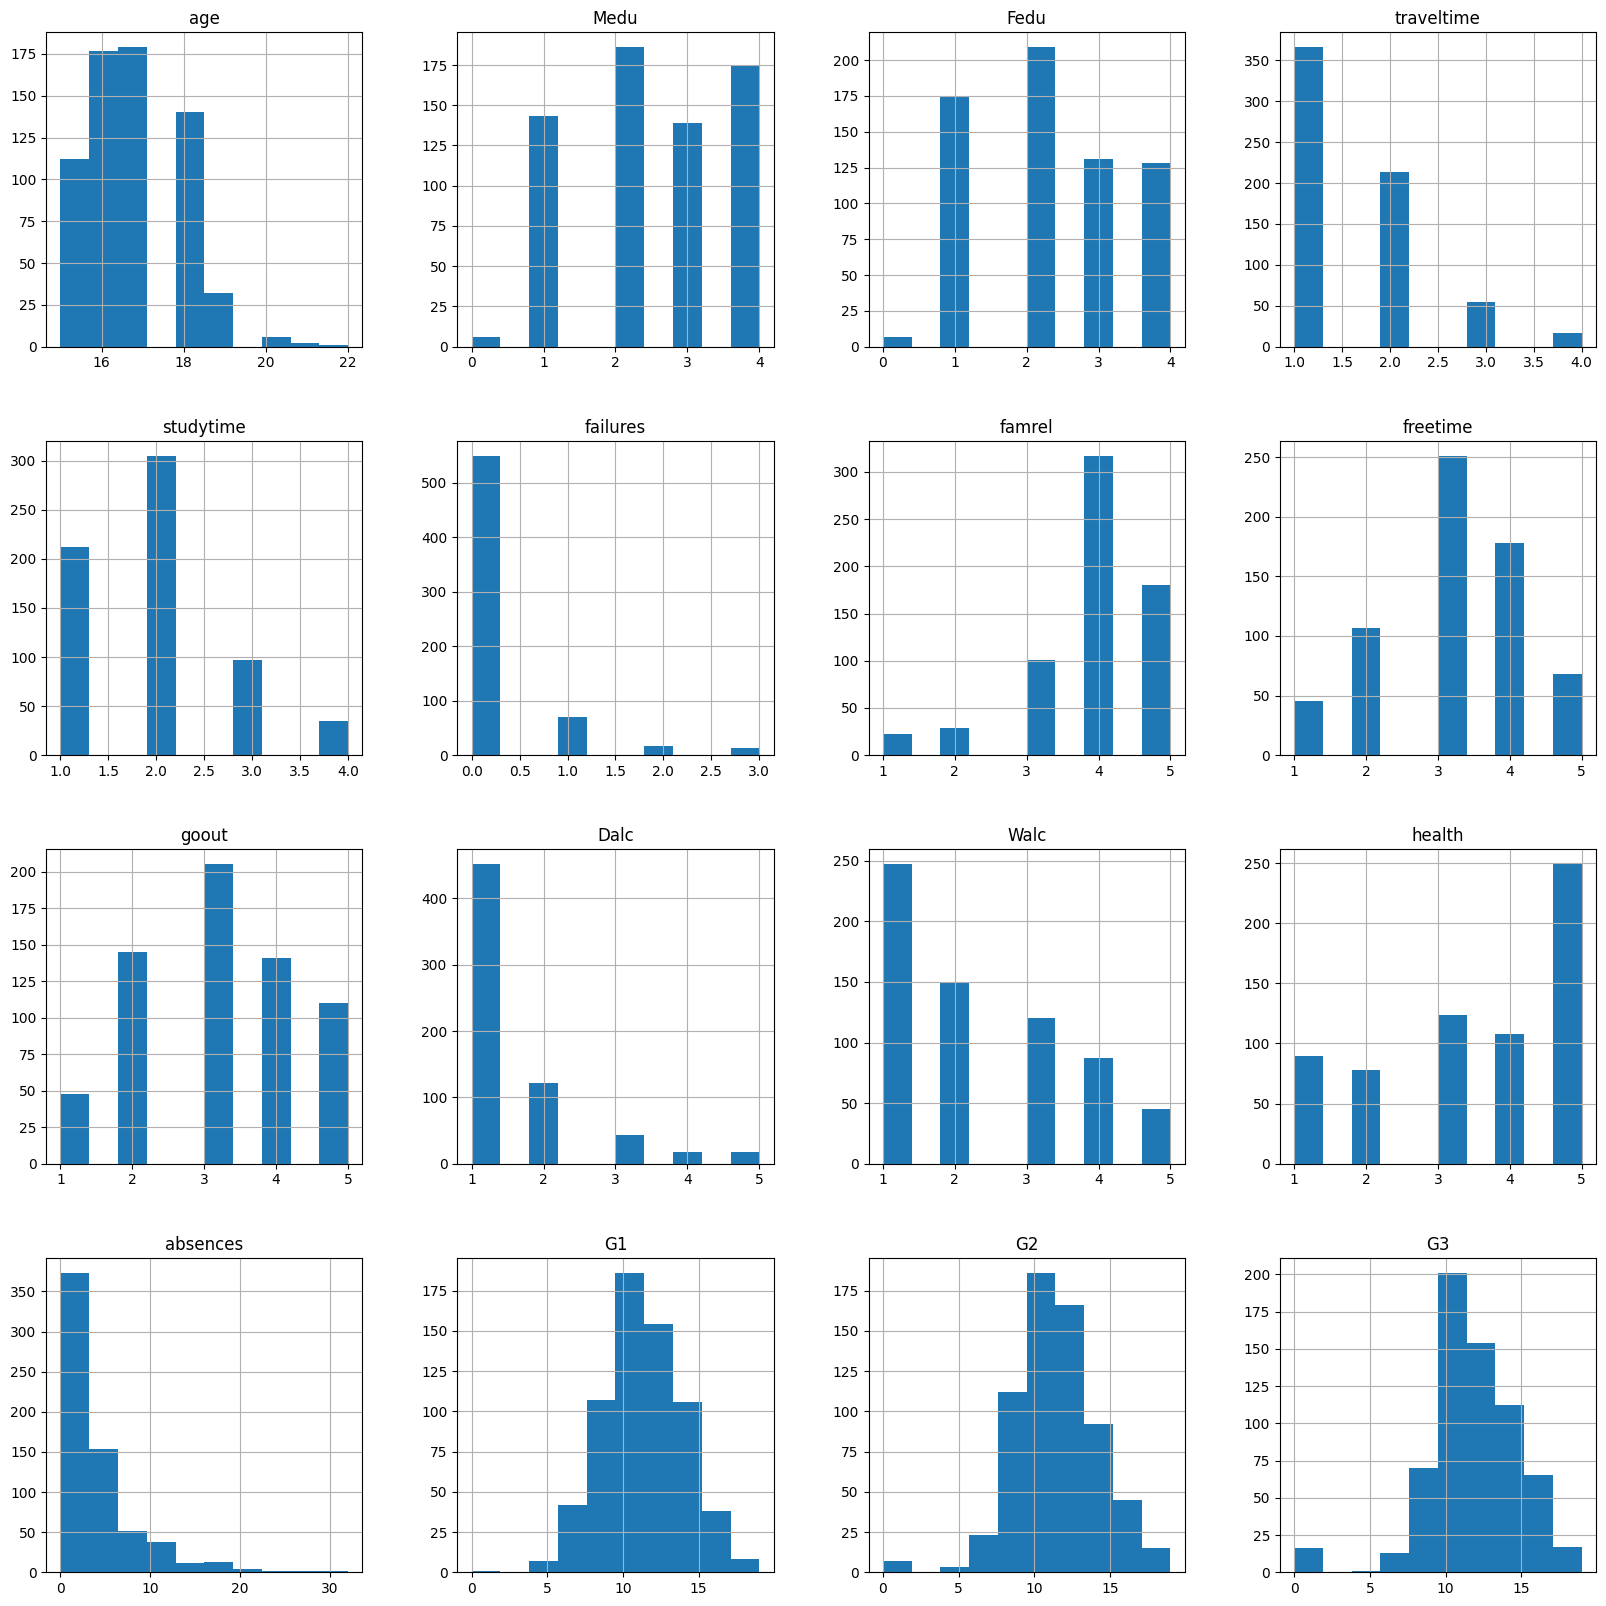

In [14]:
#Sayısal değişkenlerin dağılımlarını görmek için histogram grafikleri oluşturulmuştur.
df.hist(figsize=(20,20));


**Devamsızlık (absences) ve Final Notu (G3) İlişkisi**



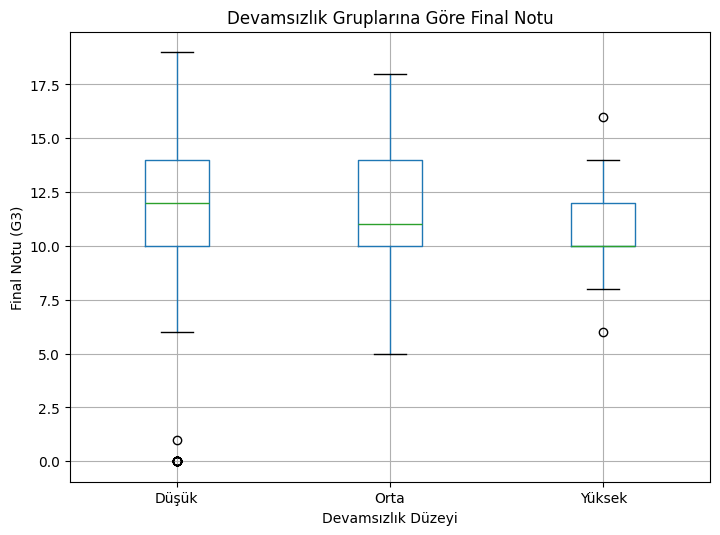

In [15]:
# Devamsızlık sayısını belirli aralıklara ayırarak kategorik bir değişken oluşturuyoruz
df['abs_group'] = pd.cut(
    df['absences'],
    bins=[-1, 5, 15, 100],
    labels=['Düşük', 'Orta', 'Yüksek']
)

# Devamsızlık gruplarına göre final notu (G3) dağılımını boxplot ile görselleştiriyoruz
df.boxplot(column='G3', by='abs_group', figsize=(8,6))

# Grafik başlık ve eksen isimlendirmeleri
plt.title('Devamsızlık Gruplarına Göre Final Notu')
plt.suptitle('')  # Otomatik gelen üst başlığı kaldırıyoruz
plt.xlabel('Devamsızlık Düzeyi')
plt.ylabel('Final Notu (G3)')

# Grafiği ekrana çizdiriyoruz
plt.show()

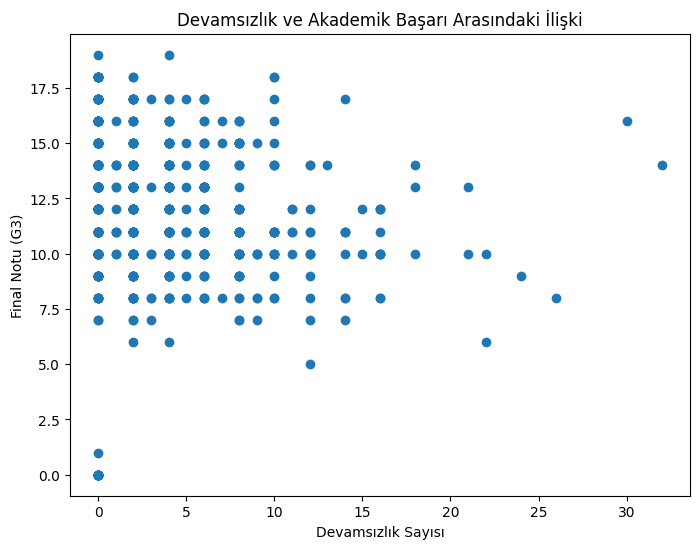

In [16]:
# Devamsızlık sayısı ile final notu (G3) arasındaki ilişkiyi incelemek için scatter plot oluşturuyoruz
plt.figure(figsize=(8,6))
plt.scatter(df['absences'], df['G3'])

# Eksen ve başlıklandırmalar
plt.xlabel('Devamsızlık Sayısı')
plt.ylabel('Final Notu (G3)')
plt.title('Devamsızlık ve Akademik Başarı Arasındaki İlişki')

# Grafiği gösteriyoruz
plt.show()



Bu grafik, öğrencilerin devamsızlık sayısı ile final notları (G3) arasındaki ilişkiyi göstermektedir. Grafik incelendiğinde, **devamsızlık arttıkça akademik başarının genel olarak azaldığı** görülmektedir.

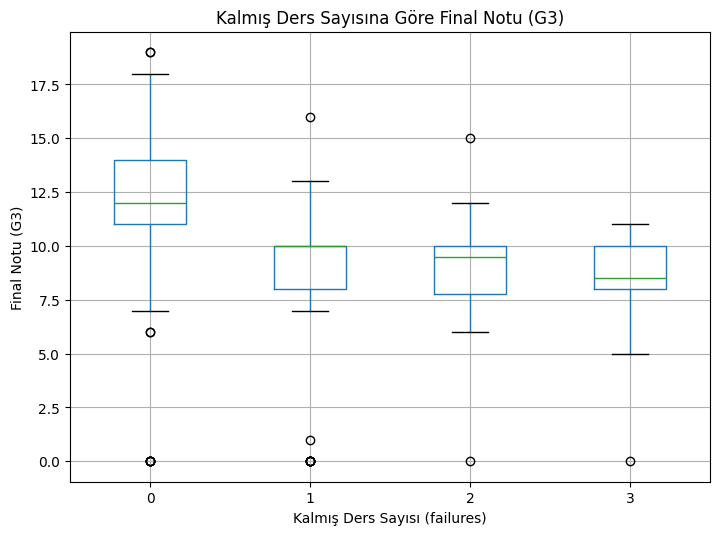

In [25]:
# Kalmış ders sayısına (failures) göre final notu (G3) dağılımını boxplot ile görselleştiriyoruz
df.boxplot(column='G3', by='failures', figsize=(8,6))

# Grafik başlık ve eksen isimlendirmeleri
plt.title('Kalmış Ders Sayısına Göre Final Notu (G3)')
plt.suptitle('')  # Otomatik gelen üst başlığı kaldırıyoruz
plt.xlabel('Kalmış Ders Sayısı (failures)')
plt.ylabel('Final Notu (G3)')

# Grafiği ekrana çizdiriyoruz
plt.show()


Grafik, kalmış ders sayısı arttıkça öğrencilerin final notu (G3) dağılımının genel olarak düştüğünü göstermektedir.

In [26]:
# Devamsızlık (absences) ile final notu (G3) arasındaki doğrusal ilişkiyi incelemek için korelasyon analizi
df[['absences', 'G3']].corr()




,absences,G3
absences,1.000000,-0.091379
G3,-0.091379,1.000000


Yapılan korelasyon analizi sonucunda, devamsızlık ile final notu arasında zayıf düzeyde negatif yönlü bir ilişki (r = -0.09) tespit edilmiştir. Bu sonuç, ters yönlü bir ilişkinin zayıf olduğunu gösterir.

**Ders Çalışma Süresi (studytime) & G3 İlişkisi**

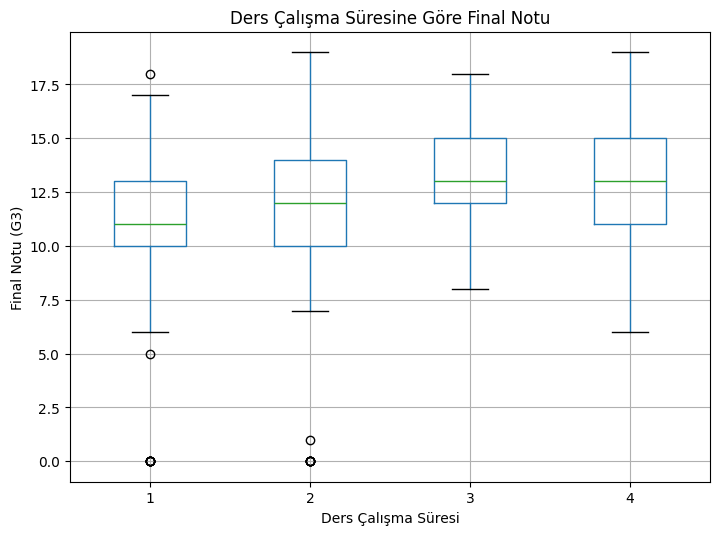

In [ ]:

# Ders çalışma süresine göre final notu (G3) dağılımını incelemek için boxplot grafiği oluşturuyoruz
df.boxplot(column='G3', by='studytime', figsize=(8,6))

# Grafik başlık ve eksen isimlendirmeleri
plt.title('Ders Çalışma Süresine Göre Final Notu')
plt.suptitle('')  # Otomatik gelen üst başlığı kaldırıyoruz
plt.xlabel('Ders Çalışma Süresi')
plt.ylabel('Final Notu (G3)')

# Grafiği gösteriyoruz
plt.show()



Elde edilen bulgulara göre, çalışma süresi arttıkça akademik başarının da arttığı gözlemlenmektedir. Bu durum, düzenli ve yeterli ders çalışma alışkanlığının öğrencilerin final başarıları üzerinde olumlu bir etkisi olduğunu göstermektedir.

EN ETKİLİ FAKTÖRLERİN BELİRLENMESİ

In [ ]:
# Sayısal değişkenlerin final notu (G3) ile olan korelasyonlarını hesaplayıp sıralıyoruz
corr_g3 = df.corr(numeric_only=True)['G3'].sort_values(ascending=False)

# Sonuçları görüntülüyoruz
corr_g3



,G3
G3,1.000000
G2,0.918548
G1,0.826387
studytime,0.249789
Medu,0.240151
Fedu,0.211800
famrel,0.063361
goout,-0.087641
absences,-0.091379
health,-0.098851


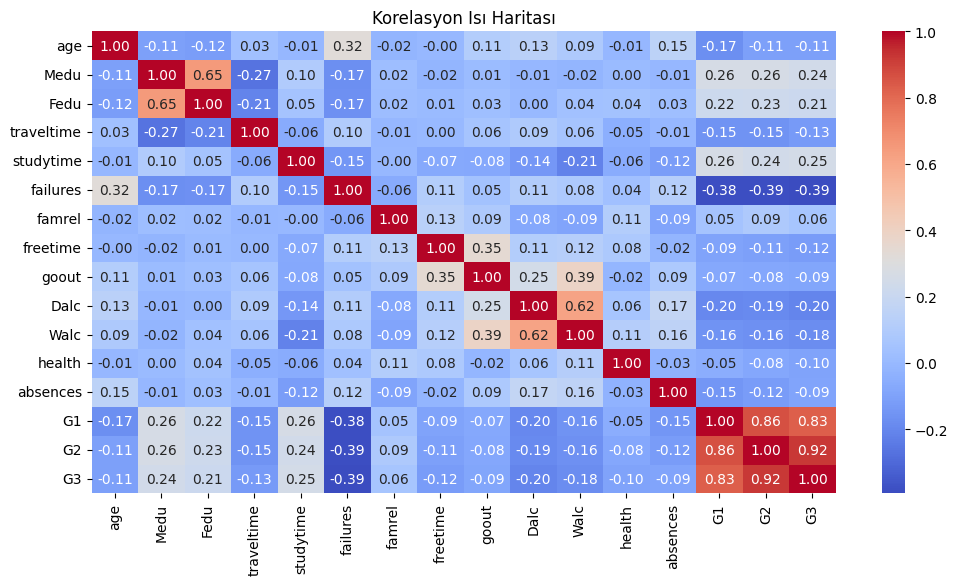

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

# Sayısal değişkenler arasındaki korelasyon katsayılarını hesaplıyoruz
# numeric_only=True parametresi sadece sayısal sütunların dikkate alınmasını sağlar
corr_matrix = df.corr(numeric_only=True)

# Korelasyon matrisini ısı haritası (heatmap) ile görselleştiriyoruz
plt.figure(figsize=(12,6))
sns.heatmap(
    corr_matrix,
    annot=True,        # Hücrelerin içine korelasyon değerlerini yazdırır
    cmap="coolwarm",   # Pozitif ve negatif korelasyonları renklerle ayırt eder
    fmt=".2f"          # Değerleri iki ondalık basamakla gösterir
)

# Grafik başlığı
plt.title("Korelasyon Isı Haritası")

# Grafiği ekrana çizdiriyoruz
plt.show()


Isı haritası, değişkenler arasındaki doğrusal ilişkileri görselleştirmektedir. Özellikle G3 değişkeninin G1 ve G2 ile yüksek pozitif korelasyona sahip olduğu, buna karşın failures ve absences gibi değişkenlerle zayıf veya negatif ilişki gösterdiği görülmektedir.

Öğrencilerin akademik başarı düzeyini sınıflandırmak.

Bu aşamada, final notu (G3) kullanılarak öğrenciler akademik başarı düzeylerine göre düşük, orta ve yüksek olmak üzere üç sınıfa ayrılmıştır.

In [ ]:
# Final notunu (G3) kategorik başarı seviyelerine ayırıyoruz
# - 0-9 → Low (Düşük Başarı)
# - 10-14 → Medium (Orta Başarı)
# - 15-20 → High (Yüksek Başarı)
df['success'] = pd.cut(
    df['G3'],
    bins=[-1, 9, 14, 20],
    labels=['Low', 'Medium', 'High']
)


In [ ]:
# Modelde kullanılacak özellikler (features) belirleniyor
features = ['G1', 'G2', 'failures', 'studytime', 'Dalc', 'Walc']

# Bağımsız değişkenler (X) seçiliyor
X = df[features]

# Bağımlı değişken / hedef değişken (y) seçiliyor
y = df['success']


Sınıflandırma modeli için, G3 ile değişkenler arasındaki korelasyonlar incelenmiş ve en güçlü korelasyona sahip olan değişkenler modele dahil edilmiştir.

In [ ]:
from sklearn.model_selection import train_test_split

# Veriyi eğitim ve test setlerine ayırıyoruz
# test_size=0.2 → %20 test, %80 eğitim
# random_state=42 → sonuçların tekrarlanabilir olması için sabit değer
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [ ]:
from sklearn.tree import DecisionTreeClassifier

# Karar ağacı sınıflandırma modeli oluşturuyoruz
# max_depth=4 → ağacın maksimum derinliği sınırlanıyor (overfitting’i önlemek için)
# random_state=42 → sonuçların tekrarlanabilirliği için sabit değer
model = DecisionTreeClassifier(max_depth=4, random_state=42)

# Modeli eğitim verisi ile eğitiyoruz
model.fit(X_train, y_train)



DecisionTreeClassifier(max_depth=4, random_state=42)

Decision Tree sınıflandırma modeli, yorumlanabilir yapısı, karmaşık istatistiksel varsayımlar gerektirmemesi ve akademik–davranışsal değişkenleri birlikte ele alabilmesi nedeniyle tercih edilmiştir. Ayrıca, veri setinin boyutu ve çalışmanın keşifsel yapısı dikkate alındığında uygun bir model olduğu düşünülmektedir.

In [ ]:
#Tahminleri alalım
y_pred = model.predict(X_test)


In [ ]:
# Model performansını değerlendirmek için gerekli kütüphaneler
from sklearn.metrics import classification_report, accuracy_score

# Test verisi ile tahmin yapıyoruz
y_pred = model.predict(X_test)

# Doğruluk oranını (accuracy) yazdırıyoruz
print("Accuracy:", accuracy_score(y_test, y_pred))

# Precision, Recall, F1-score ve destek değerlerini gösteren sınıflandırma raporu
print(classification_report(y_test, y_pred))



Accuracy: 0.8769230769230769
              precision    recall  f1-score   support

        High       0.91      1.00      0.96        32
         Low       0.55      0.73      0.63        15
      Medium       0.95      0.86      0.90        83

    accuracy                           0.88       130
   macro avg       0.80      0.86      0.83       130
weighted avg       0.89      0.88      0.88       130



Model, orta ve yüksek başarı düzeylerini yüksek doğrulukla sınıflandırırken, düşük başarı grubunda veri azlığı nedeniyle daha sınırlı bir performans sergilemektedir.

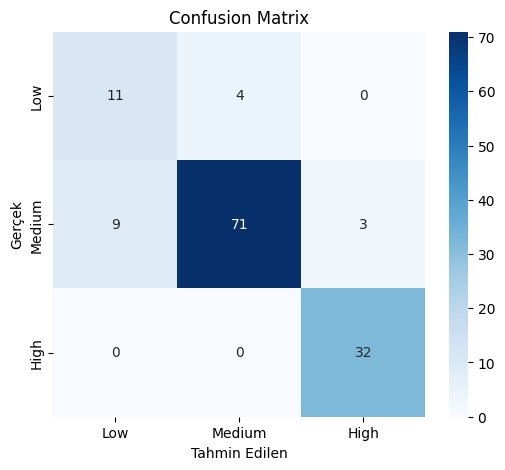

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Confusion Matrix oluştur
cm = confusion_matrix(y_test, y_pred, labels=['Low','Medium','High'])

# Heatmap ile görselleştir
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Low','Medium','High'], yticklabels=['Low','Medium','High'])
plt.xlabel('Tahmin Edilen')
plt.ylabel('Gerçek')
plt.title('Confusion Matrix')
plt.show()


Confusion Matrix ile görselleştirme, modelin hangi sınıflarda güçlü olduğunu net gösterdi.